# Theoretical analysis

Consolidated notebook for thesis Section 5. Mirrors the LaTeX structure:

1. Trajectory geometry: 3D PCA of slot states along a representative scene.
2. Spectrum and contraction: spectrum collapse, $\mathrm{tr}\,J$ and log-norm $\mu(J)$ along the trajectory.

Framing: we measure $J(s_t) = \partial f_\theta / \partial S$ along sampled trajectories. We do not prove stability; under the standard linearization implication, $\mathrm{Re}(\lambda) < 0$ at the terminal state is consistent with local contraction toward the reached state.

## 0. Setup: model, data, shared rollouts

Load the trained SlotODE checkpoint and integrate a fixed batch of validation scenes with dense `SaveAt`. Per-scene trajectories and Jacobians are cached and reused across all sections below.

In [1]:
import pickle
from pathlib import Path

import jax
jax.config.update("jax_default_matmul_precision", "highest")
import jax.numpy as jnp
import equinox as eqx
import numpy as np
import diffrax
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import seaborn as sns
from scipy.stats import gaussian_kde

from model import SlotODEModel

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)

In [2]:
CKPT_PATH = "runs_data/omkos-slotode/slot_ode_11_slots_euler_T5_dt1/checkpoints/best.eqx"
META_PATH = CKPT_PATH.replace(".eqx", "_meta.pkl")
DATA_DIR = Path("CLEVR_64")
RESOLUTION = (64, 64)
FIG_DIR = Path("thesis_draft/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

T_INT = 5.0
DT_FINE = 0.5
N_SCENES = 50
REP_SCENE_IDX = 100
INIT_SEED = 42
RNG_SEED = 0

with open(META_PATH, "rb") as f:
    meta = pickle.load(f)
args = meta["args"]
print(f"step={meta['step']}  num_iter={args['num_iter']}  dt={args.get('dt')}")

key = jax.random.key(RNG_SEED)
model = SlotODEModel(
    resolution=RESOLUTION,
    num_slots=args["num_slots"],
    slot_dim=args["slot_dim"],
    enc_hidden_dim=args.get("enc_hidden_dim", 64),
    num_iter=args["num_iter"],
    dt0=args.get("dt", None) or 1.0,
    key=key,
)
model = eqx.tree_deserialise_leaves(CKPT_PATH, model)

N_SLOTS = model.num_slots
D_SLOT = model.slot_attention_ode.slot_dim
STATE_DIM = N_SLOTS * D_SLOT
print(f"model: {N_SLOTS} slots, D={D_SLOT}, state dim={STATE_DIM}")

step=500000  num_iter=5  dt=1.0
model: 11 slots, D=64, state dim=704


In [3]:
def encode_scene(model, image):
    image_b = jnp.array(image)[None]
    enc_feat = model.enc(image_b)
    sa = model.slot_attention_ode
    feat_norm = jax.vmap(jax.vmap(sa.norm_input))(enc_feat)
    feat = jax.vmap(jax.vmap(sa.fc_input))(feat_norm)
    k = jax.vmap(jax.vmap(sa.to_k))(feat)
    v = jax.vmap(jax.vmap(sa.to_v))(feat)
    return k[0], v[0]

def integrate_fine(model, k, v, slots_0, T, dt):
    term = diffrax.ODETerm(model.slot_attention_ode.slot_ode_func)
    n_steps = int(round(T / dt))
    ts = jnp.linspace(0.0, T, n_steps + 1)
    sol = diffrax.diffeqsolve(
        term, diffrax.Euler(),
        t0=0.0, t1=T, dt0=dt,
        y0=slots_0, args=(k[None], v[None]),
        saveat=diffrax.SaveAt(ts=ts),
        stepsize_controller=diffrax.ConstantStepSize(),
        max_steps=n_steps + 16,
    )
    return np.array(sol.ts), np.array(sol.ys[:, 0])

def f_at(S_flat, k_, v_):
    S = S_flat.reshape(N_SLOTS, D_SLOT)[None]
    out = model.slot_attention_ode.slot_ode_func(0.0, S, (k_[None], v_[None]))
    return out[0].reshape(STATE_DIM)

J_fn = jax.jit(jax.jacrev(f_at, argnums=0))

def init_slots_single(model, key):
    return model.slot_attention_ode.initialize_slots(1, key)

@eqx.filter_jit
def get_masks(model, image, key):
    recon, masks, slots = model(image[None], key=key)
    return masks[0]

def jacobian_along_trajectory(model, image_np, init_key):
    """Cache one scene's trajectory + per-step Jacobian summaries.
    Returns ts, traj, k, v, eig_re, eig_im, tr, mu (log-norm).
    """
    k, v = encode_scene(model, image_np)
    s0 = init_slots_single(model, init_key)
    ts, traj = integrate_fine(model, k, v, s0, T_INT, DT_FINE)
    eig_re = np.zeros((len(ts), STATE_DIM))
    eig_im = np.zeros((len(ts), STATE_DIM))
    tr = np.zeros(len(ts))
    mu = np.zeros(len(ts))
    for ti in range(len(ts)):
        J = np.array(J_fn(jnp.array(traj[ti].flatten()), k, v))
        eigs = np.linalg.eigvals(J)
        eig_re[ti] = eigs.real
        eig_im[ti] = eigs.imag
        tr[ti] = np.trace(J)
        Jsym = 0.5 * (J + J.T)
        mu[ti] = np.linalg.eigvalsh(Jsym).max()
    return ts, traj, k, v, eig_re, eig_im, tr, mu

In [4]:
val_imgs = sorted((DATA_DIR / "images" / "val").glob("*.png"))

def load_image(idx):
    ip = val_imgs[idx]
    img = np.array(Image.open(ip).convert("RGB"), dtype=np.float32) / 127.5 - 1.0
    return np.transpose(img, (2, 0, 1))

def n_obj_for(idx):
    ip = val_imgs[idx]
    vis = np.load(DATA_DIR / "visibility" / "val" / f"{ip.stem}.npy")
    return int((vis[1:] > 0.5).sum())

# representative scene: keep full per-step Jacobians (used for ridge plot)
rep_img = load_image(REP_SCENE_IDX)
rep_n_obj = n_obj_for(REP_SCENE_IDX)
(rep_ts, rep_traj, rep_k, rep_v,
 rep_eig_re, rep_eig_im, rep_tr, rep_mu) = jacobian_along_trajectory(
    model, rep_img, jax.random.key(INIT_SEED)
)
rep_masks = np.array(get_masks(model, jnp.array(rep_img), jax.random.key(INIT_SEED)))
rep_peaks = rep_masks.max(axis=(1, 2))
rep_order = np.argsort(-rep_peaks)
rep_used = sorted(rep_order[:rep_n_obj].tolist())
rep_unused = sorted(rep_order[rep_n_obj:].tolist())
print(f"rep scene #{REP_SCENE_IDX}: {rep_n_obj} objects   used={rep_used}   unused={rep_unused}")

# aggregate across N_SCENES: keep scalar tr/mu, full traj, k/v for entropy
rng = np.random.default_rng(RNG_SEED)
scene_indices = rng.choice(len(val_imgs), size=N_SCENES, replace=False)
tr_all = np.zeros((N_SCENES, len(rep_ts)))
mu_all = np.zeros((N_SCENES, len(rep_ts)))
frac_stable_T_all = np.zeros(N_SCENES)
traj_all = np.zeros((N_SCENES, len(rep_ts), N_SLOTS, D_SLOT))
k_all, v_all = [], []

for si, idx in enumerate(scene_indices):
    img_np = load_image(int(idx))
    init_key = jax.random.key(INIT_SEED + int(idx))
    ts, traj, k, v, eig_re, eig_im, tr, mu = jacobian_along_trajectory(
        model, img_np, init_key
    )
    tr_all[si] = tr
    mu_all[si] = mu
    frac_stable_T_all[si] = (eig_re[-1] < 0).mean()
    traj_all[si] = traj
    k_all.append(k); v_all.append(v)
    if (si + 1) % 10 == 0:
        print(f"  {si+1}/{N_SCENES} done")

print()
print(f"across {N_SCENES} scenes at t=T:")
print(f"  fraction stable Re(lambda)<0: mean={frac_stable_T_all.mean():.4f}  range=[{frac_stable_T_all.min():.4f}, {frac_stable_T_all.max():.4f}]")
print(f"  tr(J): mean={tr_all[:,-1].mean():.1f}")
print(f"  mu(J): mean={mu_all[:,-1].mean():.3f}")

E0505 20:00:50.792958   11448 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0505 20:01:08.237280   11430 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


rep scene #100: 7 objects   used=[0, 1, 2, 4, 5, 7, 9]   unused=[3, 6, 8, 10]
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done

across 50 scenes at t=T:
  fraction stable Re(lambda)<0: mean=0.9899  range=[0.9858, 0.9957]
  tr(J): mean=-348.9
  mu(J): mean=2.172


## 1. Trajectory geometry (3D PCA)

Per-scene PCA on the stacked slot states $\{s_n(t)\}_{n,t}$ of the representative scene defines a 3D coordinate system in which we plot all $K$ slot trajectories. Used slots diverge to object-specific endpoints; unused slots collapse to a shared inactive attractor.

top-3 var explained: [0.367 0.248 0.162]  (cum 0.778)


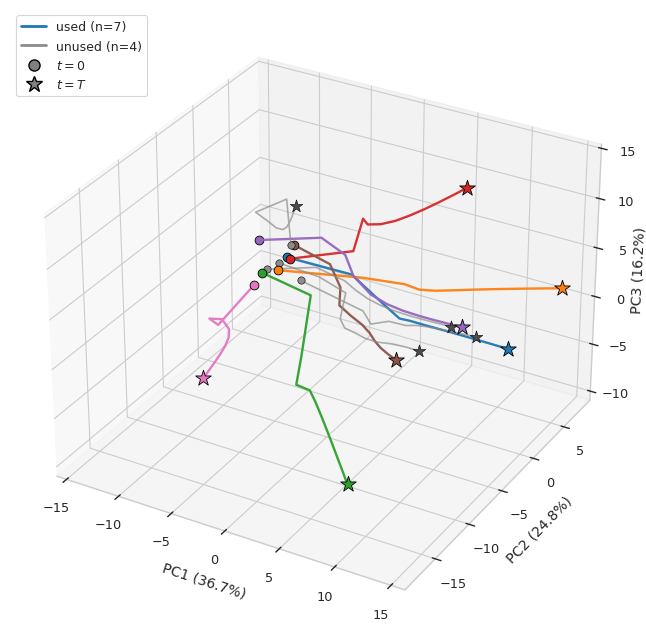

In [28]:
T_steps = rep_traj.shape[0]
X = rep_traj.reshape(T_steps * N_SLOTS, D_SLOT)
X_mean = X.mean(axis=0, keepdims=True)
Xc = X - X_mean
_, S_sv, Vt = np.linalg.svd(Xc, full_matrices=False)
var_explained = (S_sv ** 2) / (S_sv ** 2).sum()
Xp = (Xc @ Vt.T).reshape(T_steps, N_SLOTS, D_SLOT)
print(f"top-3 var explained: {var_explained[:3].round(3)}  (cum {var_explained[:3].sum():.3f})")

fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(111, projection="3d")
cmap_used = plt.cm.tab10

for i, n in enumerate(rep_used):
    c = cmap_used(i % 10)
    ax.plot(Xp[:, n, 0], Xp[:, n, 1], Xp[:, n, 2],
            "-", color=c, linewidth=1.7, alpha=0.95)
    ax.scatter(Xp[0, n, 0], Xp[0, n, 1], Xp[0, n, 2],
               color=c, marker="o", s=40, edgecolor="black", linewidth=0.6)
    ax.scatter(Xp[-1, n, 0], Xp[-1, n, 1], Xp[-1, n, 2],
               color=c, marker="*", s=140, edgecolor="black", linewidth=0.6)
for n in rep_unused:
    ax.plot(Xp[:, n, 0], Xp[:, n, 1], Xp[:, n, 2],
            "-", color="0.55", linewidth=1.2, alpha=0.7)
    ax.scatter(Xp[0, n, 0], Xp[0, n, 1], Xp[0, n, 2],
               color="0.55", marker="o", s=28, edgecolor="black", linewidth=0.4)
    ax.scatter(Xp[-1, n, 0], Xp[-1, n, 1], Xp[-1, n, 2],
               color="0.3", marker="*", s=90, edgecolor="black", linewidth=0.4)

ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({var_explained[2]*100:.1f}%)", labelpad=-2)
ax.legend(handles=[
    Line2D([0], [0], color="tab:blue", linewidth=2, label=f"used (n={len(rep_used)})"),
    Line2D([0], [0], color="0.55", linewidth=2, label=f"unused (n={len(rep_unused)})"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="black", markersize=8, label=r"$t=0$"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray",
           markeredgecolor="black", markersize=12, label=r"$t=T$"),
], fontsize=9, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "trajectory_pca3d.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Spectrum and contraction

Three views from the same per-scene Jacobians $J(s_t)$:

- **Spectrum collapse:** ridge of $\mathrm{Re}(\lambda)$ across $t$ on the representative scene.
- **Trace** $\mathrm{tr}\,J(s_t) = \sum_i \mathrm{Re}(\lambda_i)$: aggregate volume contraction. Negative ⇒ flow is dissipative.
- **Log-norm** $\mu(J(s_t)) = \lambda_{\max}\!\left(\tfrac{1}{2}(J + J^\top)\right)$: instantaneous one-sided Lipschitz rate. $\mu(J) \le -\alpha < 0$ ⇒ trajectory pairs in that region shrink monotonically in $\ell_2$. Always $\ge \max_i \mathrm{Re}(\lambda_i)$; the gap is non-normality of $J$.

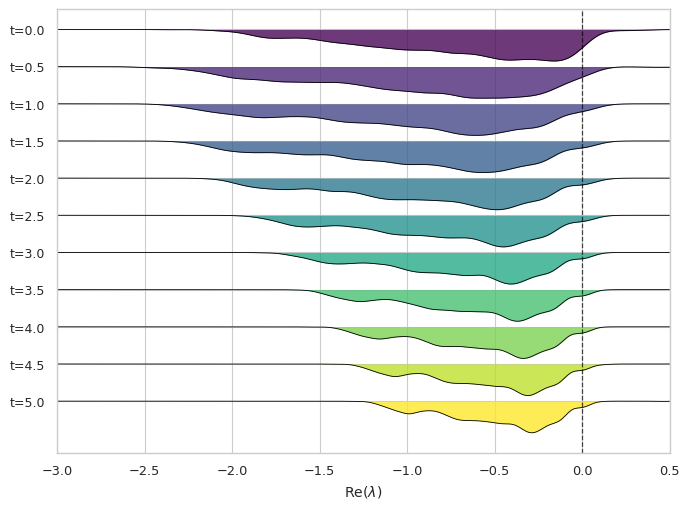

In [33]:
# Spectrum collapse: ridge of Re(lambda) across t on the representative scene.
n_t = len(rep_ts)
X_LO, X_HI = -3.0, 0.5
xs = np.linspace(X_LO, X_HI, 400)

fig, ax = plt.subplots(figsize=(7.0, 5.2))
cmap = plt.cm.viridis
ridge_height = 0.85
for i, t in enumerate(rep_ts):
    re_t = rep_eig_re[i]
    kde = gaussian_kde(re_t, bw_method=0.15)
    dens = kde(xs)
    dens = dens / dens.max() * ridge_height
    color = cmap(i / max(n_t - 1, 1))
    base = i
    ax.fill_between(xs, base, base + dens, color=color, alpha=0.78, linewidth=0)
    ax.plot(xs, base + dens, color="black", linewidth=0.6)
    # n_above = int((re_t > X_HI).sum())
    # if n_above > 0:
    #     ax.text(X_HI - 0.05, base + 0.08,
    #             f"+{n_above} >2 (max {re_t.max():.1f})",
    #             ha="right", va="bottom", fontsize=8, color="0.25")
ax.axvline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.7)
ax.set_xlim(X_LO, X_HI)
ax.set_yticks(np.arange(n_t))
ax.set_yticklabels([f"t={t:.1f}" for t in rep_ts], fontsize=9)
ax.set_xlabel(r"Re($\lambda$)")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIG_DIR / "jacobian_spectrum_ridge.png", dpi=200, bbox_inches="tight")
plt.show()

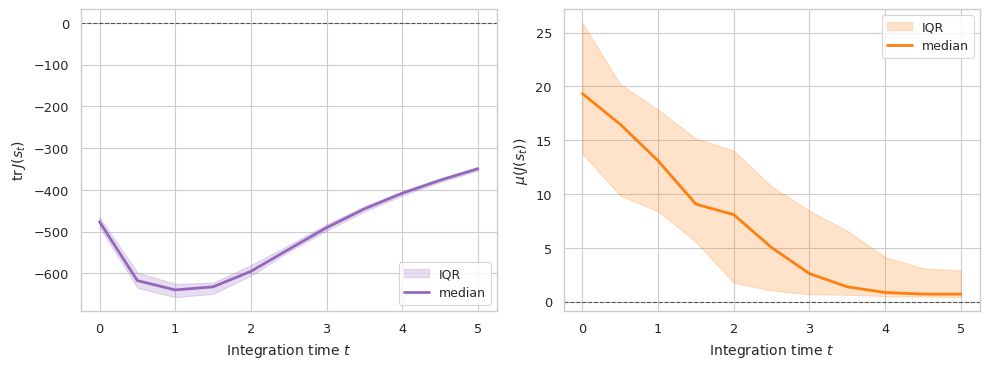

trace  t=0/T (median):   -476.0 / -349.1    mid-trajectory min: -639.4
mu(J)  t=0/T (median):   19.328 / 0.700
frac scenes with mu(T) < 0: 0.000
frac stable Re(lambda)<0 at t=T (mean over scenes): 0.9899


In [10]:
# Trace and log-norm along trajectory, median + IQR over N_SCENES.
ts = rep_ts

tr_med = np.median(tr_all, axis=0)
tr_lo = np.percentile(tr_all, 25, axis=0)
tr_hi = np.percentile(tr_all, 75, axis=0)

mu_med = np.median(mu_all, axis=0)
mu_lo = np.percentile(mu_all, 25, axis=0)
mu_hi = np.percentile(mu_all, 75, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8), sharex=True)

ax = axes[0]
ax.fill_between(ts, tr_lo, tr_hi, color="tab:purple", alpha=0.22, label="IQR")
ax.plot(ts, tr_med, color="tab:purple", linewidth=2.0, label="median")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("Integration time $t$")
ax.set_ylabel(r"$\mathrm{tr}\,J(s_t)$")
ax.legend(fontsize=9, loc="best")

ax = axes[1]
ax.fill_between(ts, mu_lo, mu_hi, color="tab:orange", alpha=0.22, label="IQR")
ax.plot(ts, mu_med, color="tab:orange", linewidth=2.0, label="median")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("Integration time $t$")
ax.set_ylabel(r"$\mu(J(s_t))$")
ax.legend(fontsize=9, loc="best")

fig.tight_layout()
fig.savefig(FIG_DIR / "jacobian_scalar_dynamics.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"trace  t=0/T (median):   {tr_med[0]:.1f} / {tr_med[-1]:.1f}    mid-trajectory min: {tr_med.min():.1f}")
print(f"mu(J)  t=0/T (median):   {mu_med[0]:.3f} / {mu_med[-1]:.3f}")
print(f"frac scenes with mu(T) < 0: {(mu_all[:, -1] < 0).mean():.3f}")
print(f"frac stable Re(lambda)<0 at t=T (mean over scenes): {frac_stable_T_all.mean():.4f}")